In [1]:
import sklearn as sl
import statsmodels as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import tensorly as tl


warnings.filterwarnings("ignore")

In [2]:
#funzioni per verificare che le serie storiche siano stazionarie
alfa = 0.05
sfas_max = 5
graf = True

def H_stazionaria(serie: pd.Series, alfa: float = 0.05) -> dict:
    """
    Esegue ADF e KPSS e restituisce un dizionario con esito e interpretazione congiunta.
 
    ADF:  H0 = serie NON stazionaria (ha radice unitaria)   -> p-value basso => stazionaria
    KPSS: H0 = serie STAZIONARIA                            -> p-value basso => NON stazionaria
 
    4 casi possibili:
      ADF stazionaria  & KPSS stazionaria      -> stazionaria
      ADF stazionaria  & KPSS non stazionaria  -> risultato incerto (verificare deriva/stagionalità)
      ADF non stazionaria & KPSS stazionaria   -> risultato incerto
      ADF non stazionaria & KPSS non stazionaria -> non stazionaria (serve differenziare)
    """
    serie = serie.dropna()
 
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(serie, autolag="AIC")
    adf_stazionaria = adf_p < alfa
 
    # regression="c" testa stazionarietà attorno a una media costante; "ct" se ha andamento deterministico
    
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie, regression="c", nlags="auto")
    kpss_stazionaria = kpss_p >= alfa
 
    if adf_stazionaria and kpss_stazionaria:
        esito = "stazionaria"
    elif not adf_stazionaria and not kpss_stazionaria:
        esito = "non stazionaria"
    else:
        esito = "incerta (ADF e KPSS in disaccordo)"
 
    return {"adf_stat": adf_stat, "adf_pvalue": adf_p, "adf_stazionaria": adf_stazionaria,
        "kpss_stat": kpss_stat, "kpss_pvalue": kpss_p, "kpss_stazionaria": kpss_stazionaria,
        "esito": esito,}

def rendi_stazionaria(serie: pd.Series, max_diff: int = 2):
    """
    Applica differenziazioni successive finché ADF+KPSS concordano su stazionarietà,
    o si raggiunge max_diff. Restituisce (serie_trasformata, num_differenze, log_test).
    """
    log = []
    corrente = serie.copy()
    for d in range(max_diff + 1):
        esito = H_stazionaria(corrente)
        log.append({"differenze": d, **esito})
        if esito["esito"] == "stazionaria":
            return corrente, d, log
        corrente = corrente.diff().dropna()
    return corrente, max_diff, log

def seleziona_ordine_ar(serie: pd.Series, sfasamenti: int = sfas_max):
    """Prova AutoReg per p = 1,...,max_lag e sceglie l'ordine con AIC minimo."""
    sfasamenti = min(sfasamenti, len(serie) // 3)  # evita sovradattamento su serie corte
    migliori = {"p": None, "aic": np.inf, "modello": None}
    for p in range(1, max(sfasamenti, 1) + 1):
        try:
            modello = AutoReg(serie, lags=p, old_names=False).fit()
            if modello.aic < migliori["aic"]:
                migliori = {"p": p, "aic": modello.aic, "modello": modello}
        except Exception:
            continue
    return migliori

In [2]:
#definizione dei dati
percorso = 'C:/Users/CdC/Desktop/studium/tirocinio/dati/puliti/completi.xlsx'
c_staz = 'stazione'
c_data = 'data'
c_geo = ['comune','provincia','latitudine','longitudine']
c_misure = ['u100_media','v100_media','tp_media','t2m_media','blh_media','bovini',	'suini',	'veg_alta',	'veg_bassa'	,'rh']
c_previsione = 'NOX_media'
freq = 'D'

tab = pd.read_excel(percorso)
tab = tab.sort_values([c_staz,c_data])
#print(tab.describe().T)
tab["vel10"] = np.sqrt(tab["u10_media"].to_numpy()**2 + tab["v10_media"].to_numpy()**2)
tab["vel100"] = np.sqrt(tab["u100_media"].to_numpy()**2 + tab["v100_media"].to_numpy()**2)

tab['mese'] = tab['data'].dt.month
regr_mens = pd.get_dummies(tab['mese'], prefix='mese',drop_first=True).astype(float)
tab = pd.concat([tab,regr_mens],axis=1)
col_mens = list(regr_mens.columns)


In [4]:
#verifiche di stazionarietà

riepilogo = []

for stazione, gruppo in tab.groupby(c_staz):
    gruppo = gruppo.set_index(c_data).sort_index()
    serie = gruppo[c_previsione]
    if freq is not None:
        serie = serie.asfreq(freq)
    serie = serie.interpolate(limit_direction="both")
        
    if serie.dropna().shape[0] < int(1826*0.4):
        print(f"[{stazione}] serie troppo corta, salto.")
        continue
    
    #test di stazionarietà sulla serie originale
    esito_originale = H_stazionaria(serie)
     
    #se non stazionaria, differenzia finché non lo è
    serie_stazionaria, n_diff, log_diff = rendi_stazionaria(serie)
     
    #selezione ordine AR e adattamento
    risultato_ar = seleziona_ordine_ar(serie_stazionaria)
    modello = risultato_ar["modello"]
    
    riga = {
        "stazione": stazione,
        "n_osservazioni": len(serie.dropna()),
        "adf_pvalue_originale": esito_originale["adf_pvalue"],
        "kpss_pvalue_originale": esito_originale["kpss_pvalue"],
        "esito_originale": esito_originale["esito"],
        "differenze_applicate": n_diff,
        "ordine_ar_p": risultato_ar["p"],
        "aic": risultato_ar["aic"],
        }
            
    if modello is not None:
        for i, coef in enumerate(modello.params):
            riga[f"coef_{i}"] = coef
    riepilogo.append(riga)
        
    if graf and modello is not None:
        fig, axes = plt.subplots(2, 2, figsize=(11, 7))
        serie.plot(ax=axes[0, 0], title=f"{stazione} - serie originale")
        serie_stazionaria.plot(ax=axes[0, 1], title=f"{stazione} - serie stazionaria (d={n_diff})")
        plot_acf(serie_stazionaria, ax=axes[1, 0], lags=min(30, len(serie_stazionaria)//2 - 1))
        plot_pacf(serie_stazionaria, ax=axes[1, 1], lags=min(30, len(serie_stazionaria)//2 - 1))
        fig.tight_layout()
        plt.close(fig)
        
        print(f"[{stazione}] esito test: {esito_originale['esito']} | "
        f"differenze: {n_diff} | AR(p={risultato_ar['p']}) AIC={risultato_ar['aic']:.2f}")
    
    riepilogo_df = pd.DataFrame(riepilogo)

[adige] esito test: stazionaria | differenze: 0 | AR(p=5) AIC=14428.68
[altamura] esito test: stazionaria | differenze: 0 | AR(p=5) AIC=14852.90
[andria] esito test: stazionaria | differenze: 0 | AR(p=5) AIC=15434.29
[archimede] esito test: incerta (ADF e KPSS in disaccordo) | differenze: 1 | AR(p=5) AIC=13309.42
[arnesano] serie troppo corta, salto.
[azienda_russo] esito test: incerta (ADF e KPSS in disaccordo) | differenze: 1 | AR(p=5) AIC=12054.17
[baldassarre] esito test: incerta (ADF e KPSS in disaccordo) | differenze: 1 | AR(p=5) AIC=9774.72
[bitonto] esito test: stazionaria | differenze: 0 | AR(p=5) AIC=12216.91
[caldarola] esito test: stazionaria | differenze: 0 | AR(p=5) AIC=15363.25
[campi] esito test: incerta (ADF e KPSS in disaccordo) | differenze: 1 | AR(p=5) AIC=13324.37
[candela_ex_comes] esito test: incerta (ADF e KPSS in disaccordo) | differenze: 1 | AR(p=5) AIC=9398.05
[candela_scuola] esito test: incerta (ADF e KPSS in disaccordo) | differenze: 1 | AR(p=5) AIC=9408.6

In [3]:
#costruzione della matrice dei coefficienti con tutte le covariate per valutare la correlazione
c_misure = ['PM10_media','PM2o5_media','NOX_media','NO2_media','NO_media','O3_media','SO2_media',
            'u10_media','v10_media','vel10','u100_media','v100_media','vel100', #0:5
            'ssrd_media','tp_media','blh_media','sp_media', #6:9
            'd2m_media','t2m_media','rh', #10:12
            'bovini','ovini','suini','pollame', #13:16
            'veg_alta',	'veg_bassa'	,'ettari_consumati','perc_suolo'] #17:20
c_previsione = 'PM10_media'

stazioni = list(set(tab['stazione']))
stazioni.sort()

istanti = list(set(tab['data']))
istanti.sort()

n_staz = len(stazioni) #64
n_regr = len(c_misure)+11+1+2
periodo = len(istanti) #1826

X_b = tl.zeros([n_staz, n_regr,periodo])
y_vera = tl.zeros([n_staz, periodo])
coord = tl.zeros([n_staz, 2])

X_b = np.column_stack([tab[c_misure],regr_mens])
for staz, ind_s in zip(stazioni,list(range(0,n_staz))):
    coord[ind_s,:] = [tab[tab['stazione']==staz][c_geo[2]].to_numpy()[0], tab[tab['stazione']==staz][c_geo[3]].to_numpy()[0]]
    y_vera[ind_s, :] = tab[tab['stazione']==staz][c_previsione].to_numpy()


import matplotlib.pyplot as plt
import seaborn as sns

X_b = pd.DataFrame(X_b)
C = X_b.corr()
#print(C)

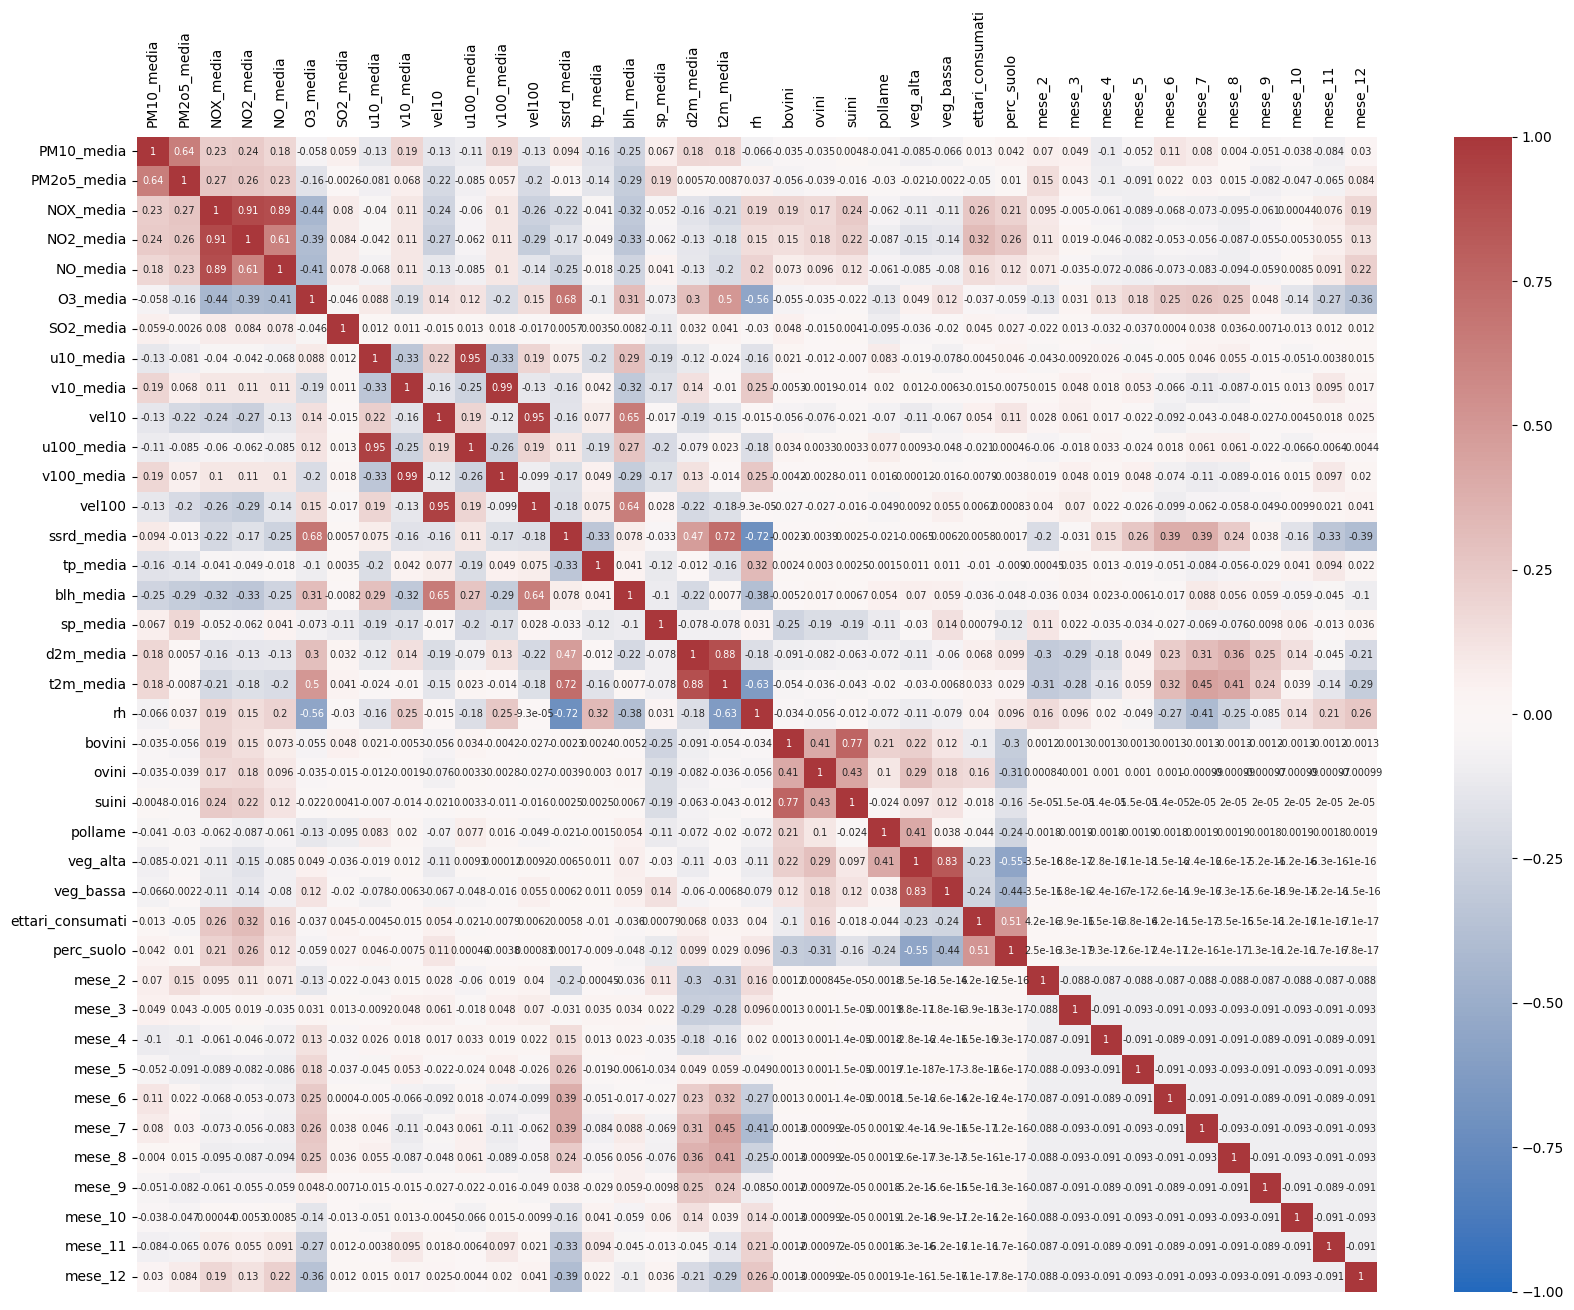

In [11]:

plt.figure(figsize=(20,15))
sns.heatmap(C, cmap='vlag', vmin=-1, vmax=1,annot = True,annot_kws={"size":7}, xticklabels=c_misure+col_mens, yticklabels=c_misure+col_mens)
plt.tick_params(axis='x', which='major', labelsize=10, labelbottom = False, bottom=False, top = False, labeltop=True, labelrotation = 90)

plt.show()

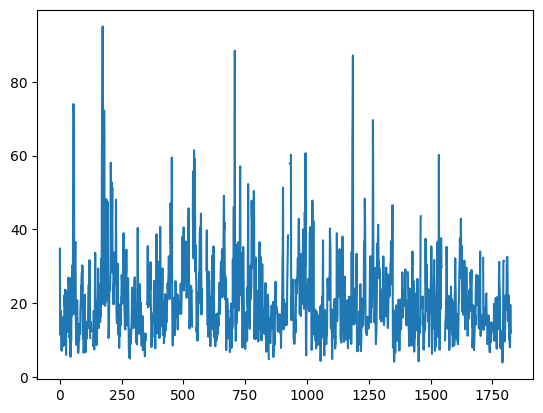

In [16]:
plt.plot(range(1826),y_vera[53,:],ms=0.5)